In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg 


In [2]:
img_array = mpimg.imread('palm_trees.jpg')

In [3]:
img_array.shape # H, W, channels

(1401, 934, 3)

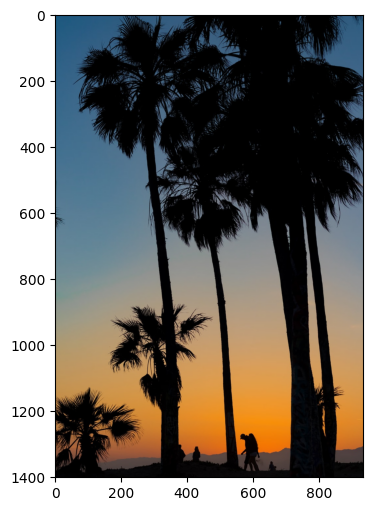

In [4]:
plt.figure(figsize = (6,6))
plt.imshow(img_array)
plt.show()

###  Convert into two dimensional array to quantize using kmeans Clu.

In [5]:
h,w,c = img_array.shape

In [6]:
img_array_2D = img_array.reshape(h*w,c)
img_array_2D.shape

(1308534, 3)

In [7]:
from sklearn.cluster import KMeans

In [8]:
model = KMeans(n_clusters= 6)

In [9]:
labels = model.fit_predict(img_array_2D)

In [13]:
labels.shape

(1308534,)

In [14]:
labels

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [17]:
model.cluster_centers_ # These are 6 clusters RGB codes (averaged/centroid of eacjh cluster like)

array([[ 72.55798641, 110.19364584, 138.04329062],
       [  2.77411297,   2.57325907,   3.68230546],
       [219.3359878 , 133.64845189,  43.9145421 ],
       [141.10236916, 145.09971306, 142.56178868],
       [ 67.27883977,  61.78895728,  62.20330006],
       [195.85055956, 154.51116792, 104.63146857]])

In [22]:
rgb_codes = model.cluster_centers_.round(0).astype(int)
rgb_codes
# These are 6 clusters center (cluster 0 has the first RGB code...and it will be assigned to the each pixel based on the cluster label of each pixel. 

array([[ 73, 110, 138],
       [  3,   3,   4],
       [219, 134,  44],
       [141, 145, 143],
       [ 67,  62,  62],
       [196, 155, 105]])

In [23]:
quantized_img = np.reshape(rgb_codes[labels], (h,w,c)) 
quantized_img

array([[[ 73, 110, 138],
        [ 73, 110, 138],
        [ 73, 110, 138],
        ...,
        [ 67,  62,  62],
        [ 73, 110, 138],
        [ 73, 110, 138]],

       [[ 73, 110, 138],
        [ 73, 110, 138],
        [ 73, 110, 138],
        ...,
        [ 67,  62,  62],
        [ 73, 110, 138],
        [ 73, 110, 138]],

       [[ 73, 110, 138],
        [ 73, 110, 138],
        [ 73, 110, 138],
        ...,
        [ 73, 110, 138],
        [ 73, 110, 138],
        [ 73, 110, 138]],

       ...,

       [[  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4],
        ...,
        [  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4]],

       [[  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4],
        ...,
        [  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4]],

       [[  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4],
        ...,
        [  3,   3,   4],
        [  3,   3,   4],
        [  3,   3,   4]]

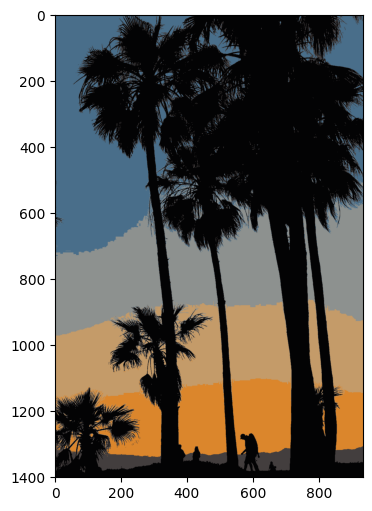

In [24]:
plt.figure(figsize = (6,6))
plt.imshow(quantized_img)